# Week 4 — GP Diagnostics (Historical Replay): Function_04

**Track:** Historical Replay, retrospective learning only. This notebook is
diagnostic/exploratory: it performs EDA and fits/compares GP surrogate
models on the Week 4 cumulative dataset. It does **not** run an acquisition
function and does **not** propose, select, or save any new query.

**Data boundary.** The Week 4 cumulative dataset for this function was built
by taking the Week 3 cumulative dataset and appending exactly one row: the
independently-verified genuine historical Week 3 query-output pair. This
notebook uses **only**:
- `../02_Data/cumulative_inputs.npy`
- `../02_Data/cumulative_outputs.npy`

No other file is loaded anywhere in this notebook. In particular, **no real
Week 4 historical query or output is loaded, revealed, or referenced** —
none exists yet for this project; this notebook works entirely with data
that was available at the end of Week 3 plus the one verified appended
Week 3 historical pair.

This function has input dimensionality **d = 4** and is a
**maximisation** problem. Official input bounds for every coordinate:
`[0.000000, 0.999999]`. Expected Week 4 cumulative row count: **33**.

**Provenance / verification trail (read for context only, not re-verified
here):**
- `Historical_Replay/Week_04/CUMULATIVE_DATA_VALIDATION.md` (PASS)
- `Historical_Replay/Week_04/INDEPENDENT_CUMULATIVE_REVIEW.md` (PASS)

This notebook independently (re-)computes its own basic sanity checks on the
loaded arrays below (shape, dtype, dimensionality, finiteness, bounds,
duplicates) rather than trusting that provenance chain blindly.

**Scope boundary:** this notebook does **not** generate, propose, or save
any new query (no acquisition function, no `03_Queries` folder anywhere),
and does **not** touch `Week_01/`, `Historical_Replay/Week_01/`,
`Historical_Replay/Week_02/`, `Historical_Replay/Week_03/`, the original
source project, or any `Week_05` location.


## 1. Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ConstantKernel

sns.set_theme(style="whitegrid")

FUNCTION_NUMBER = 4
SEED = 42 + FUNCTION_NUMBER
FIG_DIR = "../04_Figures"
os.makedirs(FIG_DIR, exist_ok=True)

print("Function number:", FUNCTION_NUMBER)
print("Seed (42 + function_number):", SEED)


Function number: 4
Seed (42 + function_number): 46


## 2. Load data

Loading only the two authorised Week 4 cumulative files for this function
from `../02_Data/`. No other file is read anywhere in this notebook.

In [2]:
inputs = np.load("../02_Data/cumulative_inputs.npy")
outputs = np.load("../02_Data/cumulative_outputs.npy")

print("inputs shape :", inputs.shape)
print("outputs shape:", outputs.shape)
print("inputs dtype :", inputs.dtype)
print("outputs dtype:", outputs.dtype)


inputs shape : (33, 4)
outputs shape: (33,)
inputs dtype : float64
outputs dtype: float64


## 3. Own sanity checks (computed, not assumed)

Even though the provenance/validation trail for this dataset already exists
and is PASS-verified (`CUMULATIVE_DATA_VALIDATION.md`,
`INDEPENDENT_CUMULATIVE_REVIEW.md`), this notebook independently
(re-)computes the basic sanity checks below directly on the loaded
arrays.

In [3]:
n_obs, d_in = inputs.shape
EXPECTED_N = 33
EXPECTED_D = 4

assert inputs.dtype == np.float64, "inputs dtype is not float64"
assert outputs.dtype == np.float64, "outputs dtype is not float64"
assert outputs.shape == (n_obs,), "outputs shape does not match number of input rows"

print("Number of observations (n):", n_obs, " | expected:", EXPECTED_N)
print("Input dimensionality (d):  ", d_in, " | expected:", EXPECTED_D)
assert n_obs == EXPECTED_N, "Row count does not match the expected Week 4 cumulative count for this function"
assert d_in == EXPECTED_D, "Input dimensionality does not match the expected value for this function"

nan_inputs = int(np.isnan(inputs).sum())
inf_inputs = int(np.isinf(inputs).sum())
nan_outputs = int(np.isnan(outputs).sum())
inf_outputs = int(np.isinf(outputs).sum())
print("NaN/Inf in inputs :", nan_inputs, inf_inputs)
print("NaN/Inf in outputs:", nan_outputs, inf_outputs)
assert nan_inputs == 0 and inf_inputs == 0, "Non-finite values found in inputs"
assert nan_outputs == 0 and inf_outputs == 0, "Non-finite values found in outputs"

rounded_inputs = np.round(inputs, 6)
unique_rows = np.unique(rounded_inputs, axis=0)
n_duplicates = n_obs - unique_rows.shape[0]
print("Duplicate input rows (after rounding to 6 dp):", n_duplicates)
assert n_duplicates == 0, "Exact duplicate rows found after rounding to 6 decimal places"

lower_ok = bool(np.all(inputs >= 0.0))
upper_ok = bool(np.all(inputs <= 0.999999))
print("All inputs >= 0.0:      ", lower_ok)
print("All inputs <= 0.999999:", upper_ok)
print("Observed input min/max:", float(inputs.min()), float(inputs.max()))
assert lower_ok and upper_ok, "Inputs outside official bounds [0.000000, 0.999999]"

print()
print("All own sanity checks PASSED.")


Number of observations (n): 33  | expected: 33
Input dimensionality (d):   4  | expected: 4
NaN/Inf in inputs : 0 0
NaN/Inf in outputs: 0 0
Duplicate input rows (after rounding to 6 dp): 0
All inputs >= 0.0:       True
All inputs <= 0.999999: True
Observed input min/max: 0.006250400244917853 0.9994825612275692

All own sanity checks PASSED.


## 4. Provenance of the final observation

The **last row** (index `n_obs - 1`) of both `cumulative_inputs.npy` and
`cumulative_outputs.npy` is the one independently-verified, genuine
historical Week 3 query-output pair that was appended on top of the Week 3
cumulative dataset to form this Week 4 cumulative dataset. Its source and
verification trail is documented in
`Historical_Replay/Week_03/Function_04/pair_provenance.md` (cited here
by reference only; this notebook does not open or programmatically read
that file, and does not load any real Week 4 historical query/output —
none exists yet). It is only *reported* below as one of the real loaded
values, not fabricated.

## 5. Descriptive statistics and best observation

Since this is a **maximisation** problem, "best" is defined as the row with
the maximum recorded output value.

In [4]:
out_min = float(outputs.min())
out_max = float(outputs.max())
out_mean = float(outputs.mean())
out_std = float(outputs.std(ddof=0))
best_idx = int(np.argmax(outputs))
best_input = inputs[best_idx].copy()
best_output = float(outputs[best_idx])
historical_idx = n_obs - 1

print("Number of observations:", n_obs)
print("Dimensionality:        ", d_in)
print("Output min :", out_min)
print("Output max :", out_max)
print("Output mean:", out_mean)
print("Output std :", out_std)
print()
print("Best observed row index:   ", best_idx)
print("Best observed input vector:", best_input)
print("Best observed output value:", best_output)
print("Is the best observation the newly-appended Week 3 historical row?", best_idx == historical_idx)
print()
print("Newly-appended historical row (index {}):".format(historical_idx))
print("  input :", inputs[historical_idx])
print("  output:", float(outputs[historical_idx]))


Number of observations: 33
Dimensionality:         4
Output min : -32.625660215962455
Output max : -1.9810750402526334
Output mean: -16.95762334746427
Output std : 7.76617535284167

Best observed row index:    32
Best observed input vector: [0.394519 0.361122 0.256803 0.461856]
Best observed output value: -1.9810750402526334
Is the best observation the newly-appended Week 3 historical row? True

Newly-appended historical row (index 32):
  input : [0.394519 0.361122 0.256803 0.461856]
  output: -1.9810750402526334


## 6. Cumulative best-observed value vs. observation number

The running maximum of the output is tracked in the dataset's existing
(index) order, from index 0 through the final row. This shows how the
best-observed value accumulated as observations were added, and marks
explicitly where the newly-appended Week 3 historical point (the final row)
falls on that curve — whether or not it improved the running best at the
time it was appended.

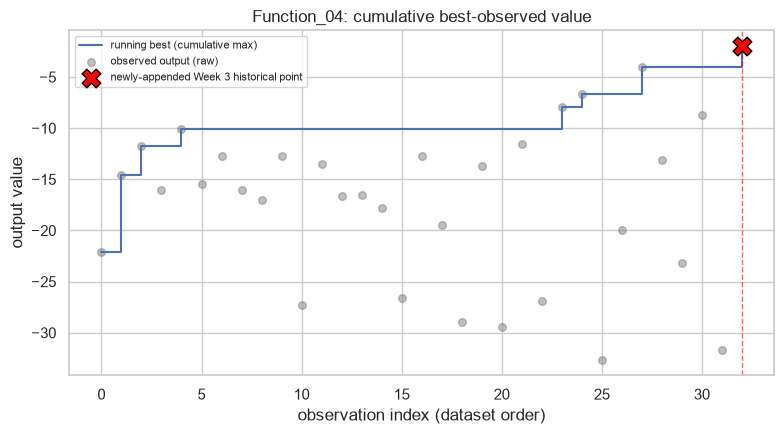

Running best just before the appended point: -4.025542281908162
Output of the appended point:                -1.9810750402526334
Running best including the appended point:   -1.9810750402526334
Did the appended point improve the running best? True


In [5]:
running_best = np.maximum.accumulate(outputs)
improved_running_best = bool(outputs[historical_idx] >= running_best[historical_idx - 1]) if historical_idx > 0 else True

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.step(np.arange(n_obs), running_best, where="post", color="C0", label="running best (cumulative max)")
ax.scatter(np.arange(n_obs), outputs, color="gray", alpha=0.5, s=30, label="observed output (raw)")
ax.scatter([historical_idx], [outputs[historical_idx]], color="red", marker="X", s=180,
           edgecolor="black", zorder=5, label="newly-appended Week 3 historical point")
ax.axvline(historical_idx, color="red", linestyle="--", linewidth=1, alpha=0.6)
ax.set_xlabel("observation index (dataset order)")
ax.set_ylabel("output value")
ax.set_title(f"Function_{FUNCTION_NUMBER:02d}: cumulative best-observed value")
ax.legend(fontsize=8, loc="best")
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "cumulative_best_observed.png"), dpi=150)
plt.show()

print("Running best just before the appended point:", float(running_best[historical_idx - 1]) if historical_idx > 0 else None)
print("Output of the appended point:               ", float(outputs[historical_idx]))
print("Running best including the appended point:  ", float(running_best[historical_idx]))
print("Did the appended point improve the running best?", improved_running_best)


## 7. Exploratory input-output figures

### 7b. Per-feature scatter plots (each input dimension vs. output)

One subplot per input dimension. The newly-appended historical point is
plotted with a distinct marker/color in every subplot.

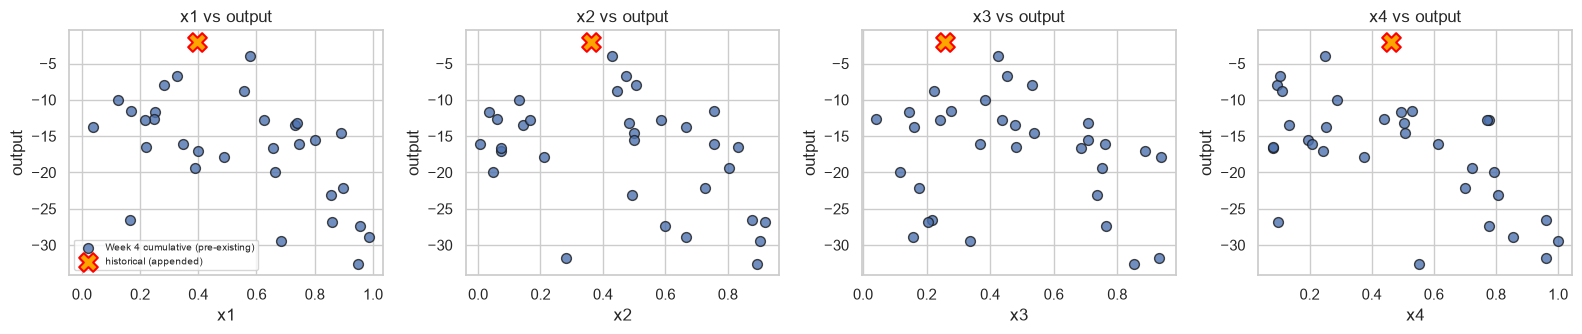

In [6]:
d_in_local = inputs.shape[1]
ncols = min(d_in_local, 4)
nrows = int(np.ceil(d_in_local / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows), squeeze=False)
orig_mask = np.arange(n_obs) != historical_idx

for i in range(d_in_local):
    r, c = divmod(i, ncols)
    ax = axes[r][c]
    ax.scatter(inputs[orig_mask, i], outputs[orig_mask], s=50, edgecolor="k",
               alpha=0.8, label="Week 4 cumulative (pre-existing)")
    ax.scatter(inputs[historical_idx, i], outputs[historical_idx], marker="X", s=180,
               edgecolor="red", facecolor="orange", linewidth=1.5, label="historical (appended)")
    ax.set_xlabel(f"x{i+1}")
    ax.set_ylabel("output")
    ax.set_title(f"x{i+1} vs output")
    if i == 0:
        ax.legend(fontsize=7, loc="best")

for j in range(d_in_local, nrows * ncols):
    r, c = divmod(j, ncols)
    axes[r][c].axis("off")

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "eda_features_vs_output.png"), dpi=150)
plt.show()


### 7c. Distribution of observed output values

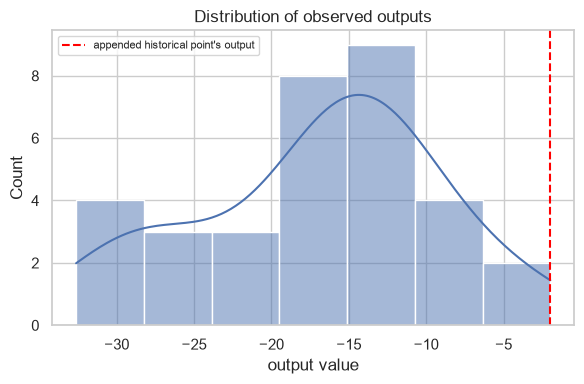

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(outputs, kde=True, ax=ax)
ax.axvline(outputs[historical_idx], color="red", linestyle="--",
           label="appended historical point's output")
ax.set_xlabel("output value")
ax.set_title("Distribution of observed outputs")
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "output_histogram.png"), dpi=150)
plt.show()


## 8. GP surrogate model — RBF vs. Matérn kernels

**Output standardization.** Output scales vary enormously across the 8
functions, which can badly condition GP hyperparameter optimisation and
make kernel hyperparameters hard to compare across functions. The output
`y` is therefore standardized (zero mean, unit variance) *before* fitting,
and every posterior value reported or plotted below is transformed back to
the original output scale via `inverse_mean`/`inverse_std` before being
used. Inputs are **not** rescaled — they are already confined to the
official `[0, 0.999999]` domain by construction. This is the same
standardisation approach used in Week 2 and Week 3.

**Kernel choice.** Two GP surrogates are fitted and compared, using the
same construction as Week 2 and Week 3:
- `ConstantKernel * RBF + WhiteKernel`,
- `ConstantKernel * Matern(nu=2.5) + WhiteKernel`.

A `WhiteKernel` (observation-noise) term is retained for all 8 functions as
a conservative, consistent modelling choice, as established in Week 2 (the
Week 2 cumulative-data review found evidence, for some functions, of
near-duplicate inputs with non-identical outputs, which could not be ruled
out as measurement noise).

**Fitting details.** `n_restarts_optimizer=5`, `random_state = 42 +
function_number` (= 46 here), `alpha=1e-10` (tiny numerical jitter
only — actual observation noise is handled by the `WhiteKernel` term, not
by `alpha`).

In [8]:
y_mean = float(outputs.mean())
y_std = float(outputs.std(ddof=0))
if y_std == 0.0:
    y_std = 1.0
y_scaled = (outputs - y_mean) / y_std

print("Output mean (for standardization):", y_mean)
print("Output std  (for standardization):", y_std)


def inverse_mean(m):
    """Map a standardized posterior mean back to the original output scale."""
    return m * y_std + y_mean


def inverse_std(s):
    """Map a standardized posterior std-dev back to the original output scale."""
    return s * y_std


def build_kernel(kernel_type, d):
    length_scale_init = np.ones(d)
    if kernel_type == "rbf":
        base_kernel = RBF(length_scale=length_scale_init, length_scale_bounds=(1e-2, 1e2))
    elif kernel_type == "matern":
        base_kernel = Matern(length_scale=length_scale_init, length_scale_bounds=(1e-2, 1e2), nu=2.5)
    else:
        raise ValueError(kernel_type)
    return ConstantKernel(1.0, (1e-2, 1e2)) * base_kernel \
        + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-10, 1e1))


def build_and_fit(kernel_type):
    d = inputs.shape[1]
    kernel = build_kernel(kernel_type, d)
    gpr = GaussianProcessRegressor(
        kernel=kernel,
        alpha=1e-10,
        n_restarts_optimizer=5,
        normalize_y=False,
        random_state=SEED,
    )
    gpr.fit(inputs, y_scaled)
    return gpr


gpr_rbf = build_and_fit("rbf")
gpr_matern = build_and_fit("matern")

print("Fitting complete for both kernels.")


Output mean (for standardization): -16.95762334746427
Output std  (for standardization): 7.76617535284167
Fitting complete for both kernels.


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


### 8a. Fitted hyperparameters and log-marginal-likelihood

In [9]:
def extract_params(gpr):
    k = gpr.kernel_
    const = k.k1.k1
    base = k.k1.k2
    noise = k.k2
    return {
        "constant_value": float(const.constant_value),
        "length_scale": np.atleast_1d(base.length_scale).astype(float),
        "noise_level": float(noise.noise_level),
    }


results = {}
for name, gpr in [("rbf", gpr_rbf), ("matern", gpr_matern)]:
    params = extract_params(gpr)
    lml = float(gpr.log_marginal_likelihood_value_)
    results[name] = {"gpr": gpr, "params": params, "lml": lml}
    print(f"--- {name.upper()} ---")
    print("Fitted kernel:      ", gpr.kernel_)
    print("Output-scale const :", params["constant_value"])
    print("Length-scale(s)    :", params["length_scale"])
    print("Noise level        :", params["noise_level"])
    print("Log-marginal-lik.  :", lml)
    print()

better_by_lml = max(results, key=lambda k: results[k]["lml"])
print("Higher raw log-marginal-likelihood on this dataset:", better_by_lml.upper())


--- RBF ---
Fitted kernel:       2.09**2 * RBF(length_scale=[0.811, 0.745, 0.776, 0.79]) + WhiteKernel(noise_level=1e-10)
Output-scale const : 4.374037575103856
Length-scale(s)    : [0.8108287  0.74464359 0.77554844 0.79046453]
Noise level        : 9.999999999999996e-11
Log-marginal-lik.  : -15.518598610350416

--- MATERN ---
Fitted kernel:       4.77**2 * Matern(length_scale=[2.14, 1.96, 2.1, 2.02], nu=2.5) + WhiteKernel(noise_level=1e-10)
Output-scale const : 22.72806480010582
Length-scale(s)    : [2.13693342 1.96330594 2.09539516 2.02092326]
Noise level        : 9.999999999999996e-11
Log-marginal-lik.  : -15.254226176895251

Higher raw log-marginal-likelihood on this dataset: MATERN


### 8b. Convergence-aware per-restart diagnostic (all 8 functions)

Raw log-marginal-likelihood comparisons are not, by themselves, a
trustworthy basis for kernel selection unless the underlying optimizer
search actually converged reliably. The cell below replays the **exact
same** kernel construction, `random_state = 46`, and
`n_restarts_optimizer=5` search used by `build_and_fit()` above for both
kernels, but instruments each of the 6 individual L-BFGS-B optimizer calls
per kernel (1 from the kernel's default initial `theta`, plus 5 random
restarts) to record per-call convergence status and log-marginal-likelihood
(LML). This is a **read-only diagnostic**: it uses a separate, throwaway
`GaussianProcessRegressor` instance and does not modify `gpr_rbf`,
`gpr_matern`, `n_restarts_optimizer`, the seed, `alpha`, or any value
reported/plotted elsewhere in this notebook, and it does **not** suppress
any warning (a wrapper forwards every warning to the default handler in
addition to recording it for structured reporting). This is the same
per-restart instrumentation approach first applied to Function_05 in
Week 2's remediation, applied uniformly to all 8 functions in Week 3 and
again here in Week 4.

In [10]:
import warnings as _warnings


def _diagnose_restarts(kernel_type):
    """Diagnostic-only: replays the same kernel construction, SEED, and
    n_restarts_optimizer=5 restart search as build_and_fit(kernel_type)
    above, but records the convergence status and LML of each individual
    optimizer call. Does NOT modify gpr_rbf/gpr_matern or any value used
    elsewhere in this notebook; it builds and fits its own separate,
    throwaway GaussianProcessRegressor instance."""
    d = inputs.shape[1]
    kernel = build_kernel(kernel_type, d)

    diag_gpr = GaussianProcessRegressor(
        kernel=kernel,
        alpha=1e-10,
        n_restarts_optimizer=5,
        normalize_y=False,
        random_state=SEED,
    )

    records = []
    _orig_constrained_opt = diag_gpr._constrained_optimization

    def _instrumented(obj_func, initial_theta, bounds):
        captured_msgs = []
        default_showwarning = _warnings.showwarning

        def _capture_and_still_show(message, category, filename, lineno, file=None, line=None):
            # Record the warning for structured reporting below, AND still
            # forward it to the default handler so it remains visible in
            # this cell's own output (warnings are NOT suppressed).
            captured_msgs.append(str(message))
            default_showwarning(message, category, filename, lineno, file, line)

        with _warnings.catch_warnings():
            _warnings.simplefilter("always")
            _warnings.showwarning = _capture_and_still_show
            theta_opt, func_min = _orig_constrained_opt(obj_func, initial_theta, bounds)

        abnormal = any("ABNORMAL" in m for m in captured_msgs)
        records.append({"lml": -func_min, "abnormal": abnormal})
        return theta_opt, func_min

    diag_gpr._constrained_optimization = _instrumented
    diag_gpr.fit(inputs, y_scaled)

    print(f"--- {kernel_type.upper()} per-restart diagnostic (SEED={SEED}) ---")
    for i, r in enumerate(records):
        tag = "initial-theta run" if i == 0 else f"random restart {i}"
        status = "ABNORMAL termination" if r["abnormal"] else "converged"
        print(f"  [{tag:18s}] LML = {r['lml']: .6f}   status = {status}")
    n_abnormal = sum(r["abnormal"] for r in records)
    best_i = int(np.argmax([r["lml"] for r in records]))
    best_tag = "initial-theta run" if best_i == 0 else f"random restart {best_i}"
    print(f"  -> {n_abnormal}/{len(records)} optimizer calls terminated ABNORMAL")
    print(f"  -> best-LML (selected) run: {best_tag}, "
          f"status = {'ABNORMAL' if records[best_i]['abnormal'] else 'converged'}")
    print()
    return records, n_abnormal


rbf_diag_records, rbf_n_abnormal = _diagnose_restarts("rbf")
matern_diag_records, matern_n_abnormal = _diagnose_restarts("matern")

print("Summary: RBF ABNORMAL restarts = {}/6, Matern ABNORMAL restarts = {}/6".format(
    rbf_n_abnormal, matern_n_abnormal))


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


--- RBF per-restart diagnostic (SEED=46) ---
  [initial-theta run ] LML = -15.518599   status = converged
  [random restart 1  ] LML = -15.518599   status = converged
  [random restart 2  ] LML = -46.824972   status = converged
  [random restart 3  ] LML = -15.518599   status = converged
  [random restart 4  ] LML = -15.518599   status = converged
  [random restart 5  ] LML = -46.824965   status = converged
  -> 0/6 optimizer calls terminated ABNORMAL
  -> best-LML (selected) run: random restart 3, status = converged

--- MATERN per-restart diagnostic (SEED=46) ---
  [initial-theta run ] LML = -15.254226   status = converged
  [random restart 1  ] LML = -15.254226   status = converged
  [random restart 2  ] LML = -46.824954   status = converged
  [random restart 3  ] LML = -15.254226   status = converged
  [random restart 4  ] LML = -15.255197   status = converged
  [random restart 5  ] LML = -15.254226   status = converged
  -> 0/6 optimizer calls terminated ABNORMAL
  -> best-LML (se

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


### 8c. Convergence-aware model-selection rule (applied here, as established in Week 2's remediation)

This notebook applies, verbatim, the same convergence-aware kernel-selection
rule documented and first applied to Function_05 in
`Historical_Replay/Week_02/REMEDIATION_REPORT.md`:

> "Prefer the kernel with fewer/no `ABNORMAL` optimizer terminations across
> restarts. If both kernels converge cleanly, prefer the higher
> log-marginal-likelihood. If neither kernel converges reliably across
> restarts, do not select either as 'the model' for this function — report
> both as exploratory only."

The cell below applies this rule **programmatically** to the per-restart
diagnostic counts computed in 8b above (not hand-picked), and prints the
resulting decision for this function explicitly.

In [11]:
if rbf_n_abnormal == 0 and matern_n_abnormal == 0:
    # Both converge cleanly -> tie-break on higher log-marginal-likelihood.
    selected_kernel_name = "rbf" if results["rbf"]["lml"] >= results["matern"]["lml"] else "matern"
    decision_reason = (
        "Both kernels converged cleanly across all 6 restart attempts each "
        "(0/6 ABNORMAL terminations for both). Per the rule, the tie-breaker "
        "is higher log-marginal-likelihood, which favors {}.".format(selected_kernel_name.upper())
    )
elif rbf_n_abnormal != matern_n_abnormal:
    # Unequal ABNORMAL counts -> prefer the kernel with fewer, regardless of raw LML.
    selected_kernel_name = "rbf" if rbf_n_abnormal < matern_n_abnormal else "matern"
    decision_reason = (
        "The two kernels did not converge equally reliably across restarts "
        "(RBF: {}/6 ABNORMAL, Matern: {}/6 ABNORMAL). Per the rule, the "
        "kernel with fewer ABNORMAL terminations is preferred as the more "
        "convergence-reliable candidate ({}), even though this may not be "
        "the kernel with the higher raw log-marginal-likelihood.".format(
            rbf_n_abnormal, matern_n_abnormal, selected_kernel_name.upper())
    )
else:
    # Equal, non-zero ABNORMAL counts on both -> neither is reliable.
    selected_kernel_name = None
    decision_reason = (
        "Both kernels show the same, non-zero number of ABNORMAL restart "
        "terminations ({}/6 each). Per the rule, neither kernel converges "
        "reliably enough to be selected as 'the model' for this function. "
        "**Both are reported as exploratory only.**".format(rbf_n_abnormal)
    )

print("DECISION:", "NEITHER (both exploratory only)" if selected_kernel_name is None
      else selected_kernel_name.upper())
print()
print(decision_reason)


DECISION: MATERN

Both kernels converged cleanly across all 6 restart attempts each (0/6 ABNORMAL terminations for both). Per the rule, the tie-breaker is higher log-marginal-likelihood, which favors MATERN.


### 8d. Convergence-stability caveat for this function this week (computed, not hand-picked)

The cell below prints an explicit, dynamically-computed caveat about
convergence reliability for **this** function's Week 4 fit, based directly
on the `rbf_n_abnormal`/`matern_n_abnormal` counts from 8b above. This is
the same honesty check applied in Week 3: if either kernel shows any
`ABNORMAL` terminations, that is stated plainly rather than glossed over,
regardless of which kernel the rule in 8c ends up selecting.

In [12]:
if rbf_n_abnormal == 0 and matern_n_abnormal == 0:
    print("Both kernels converged cleanly across all 6 restart attempts each "
          "(0/6 ABNORMAL terminations for both) for Function_{:02d} this week. "
          "No convergence-instability caveat applies.".format(FUNCTION_NUMBER))
elif selected_kernel_name is not None:
    print("CAVEAT: convergence instability was observed for Function_{:02d} this week "
          "(RBF: {}/6 ABNORMAL, Matern: {}/6 ABNORMAL). The kernel with fewer ABNORMAL "
          "terminations ({}) is treated, per the rule, as only the MARGINALLY more "
          "convergence-reliable of the two exploratory candidates -- this is NOT the "
          "same as a clean, fully reliable fit, and it is not necessarily the kernel "
          "with the higher raw log-marginal-likelihood.".format(
              FUNCTION_NUMBER, rbf_n_abnormal, matern_n_abnormal, selected_kernel_name.upper()))
else:
    print("CAVEAT: neither kernel converges reliably for Function_{:02d} this week "
          "(RBF: {}/6 ABNORMAL, Matern: {}/6 ABNORMAL, equal and non-zero). Per the "
          "rule, NEITHER kernel is selected as 'the model' for this function -- both "
          "are reported as exploratory only in Section 9 below.".format(
              FUNCTION_NUMBER, rbf_n_abnormal, matern_n_abnormal))


Both kernels converged cleanly across all 6 restart attempts each (0/6 ABNORMAL terminations for both) for Function_04 this week. No convergence-instability caveat applies.


## 9. Model-diagnostic figures

The figure(s) below cover the selected kernel from Section 8c above (or, in
the rare case that the rule concludes neither kernel is reliable, both
kernels are shown side by side as exploratory-only).

**In-sample limitation, stated explicitly.** Given the very small dataset
sizes in this project (as few as 13, and at most 43, observations), a
proper leave-one-out or other held-out evaluation was judged likely to be
unstably estimated and was not the primary approach used here. The
observed-vs-predicted and residual diagnostics below are computed
**in-sample** (i.e. the GP predicts on the same points it was fitted on).
This is a real limitation, not hidden: in-sample fit quality for a GP with
a `WhiteKernel` noise term does **not** establish generalisation to unseen
points, and should not be over-interpreted as validation.

In [13]:
models_to_diagnose = [selected_kernel_name] if selected_kernel_name is not None else ["rbf", "matern"]
model_lookup = {"rbf": gpr_rbf, "matern": gpr_matern}
print("Model(s) used for Section 9 diagnostics:", [m.upper() for m in models_to_diagnose])


Model(s) used for Section 9 diagnostics: ['MATERN']


### 9a. Observed vs. predicted (in-sample), with uncertainty error bars

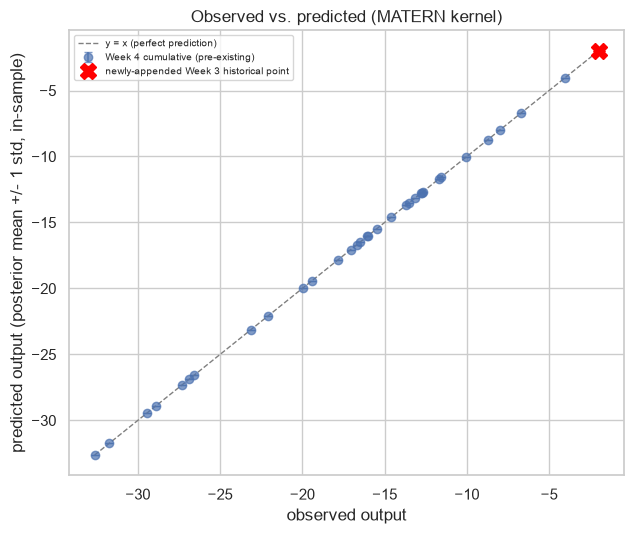

In [14]:
fig, axes = plt.subplots(1, len(models_to_diagnose), figsize=(6.5 * len(models_to_diagnose), 5.5), squeeze=False)

for j, name in enumerate(models_to_diagnose):
    ax = axes[0][j]
    gpr = model_lookup[name]
    pred_mean_s, pred_std_s = gpr.predict(inputs, return_std=True)
    pred_mean = inverse_mean(pred_mean_s)
    pred_std = inverse_std(pred_std_s)

    orig_mask = np.arange(n_obs) != historical_idx
    ax.errorbar(outputs[orig_mask], pred_mean[orig_mask], yerr=pred_std[orig_mask],
                fmt="o", color="C0", ecolor="C0", alpha=0.7, capsize=3,
                label="Week 4 cumulative (pre-existing)")
    ax.errorbar([outputs[historical_idx]], [pred_mean[historical_idx]], yerr=[pred_std[historical_idx]],
                fmt="X", color="red", ecolor="red", markersize=12, capsize=4,
                label="newly-appended Week 3 historical point")

    lims = [min(outputs.min(), pred_mean.min() - pred_std.max()),
            max(outputs.max(), pred_mean.max() + pred_std.max())]
    ax.plot(lims, lims, color="gray", linestyle="--", linewidth=1, label="y = x (perfect prediction)")
    ax.set_xlabel("observed output")
    ax.set_ylabel("predicted output (posterior mean +/- 1 std, in-sample)")
    ax.set_title(f"Observed vs. predicted ({name.upper()} kernel)")
    ax.legend(fontsize=7, loc="best")

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "observed_vs_predicted.png"), dpi=150)
plt.show()


### 9b. Residual diagnostics

Residuals are computed as `observed - predicted` on the original output
scale (in-sample), plotted against both the predicted value and the
observation index, to visually check for systematic patterns (a well-fit
model should show residuals scattered roughly randomly around zero, with no
obvious trend).

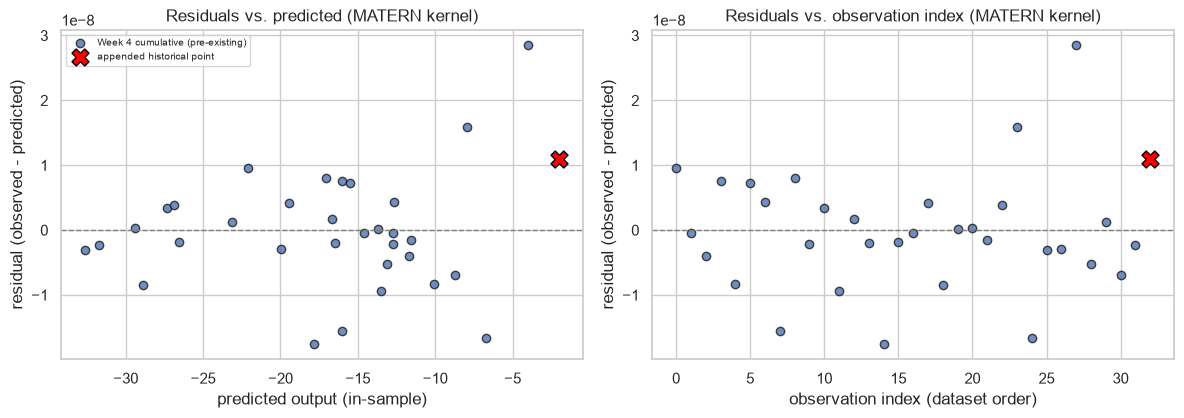

In [15]:
fig, axes = plt.subplots(len(models_to_diagnose), 2, figsize=(12, 4.5 * len(models_to_diagnose)), squeeze=False)

for j, name in enumerate(models_to_diagnose):
    gpr = model_lookup[name]
    pred_mean_s, _ = gpr.predict(inputs, return_std=True)
    pred_mean = inverse_mean(pred_mean_s)
    residuals = outputs - pred_mean
    orig_mask = np.arange(n_obs) != historical_idx

    ax = axes[j][0]
    ax.scatter(pred_mean[orig_mask], residuals[orig_mask], color="C0", edgecolor="k", alpha=0.8,
               label="Week 4 cumulative (pre-existing)")
    ax.scatter([pred_mean[historical_idx]], [residuals[historical_idx]], color="red", marker="X",
               s=150, edgecolor="black", label="appended historical point")
    ax.axhline(0.0, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel("predicted output (in-sample)")
    ax.set_ylabel("residual (observed - predicted)")
    ax.set_title(f"Residuals vs. predicted ({name.upper()} kernel)")
    if j == 0:
        ax.legend(fontsize=7, loc="best")

    ax = axes[j][1]
    ax.scatter(np.arange(n_obs)[orig_mask], residuals[orig_mask], color="C0", edgecolor="k", alpha=0.8)
    ax.scatter([historical_idx], [residuals[historical_idx]], color="red", marker="X",
               s=150, edgecolor="black")
    ax.axhline(0.0, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel("observation index (dataset order)")
    ax.set_ylabel("residual (observed - predicted)")
    ax.set_title(f"Residuals vs. observation index ({name.upper()} kernel)")

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "residual_diagnostics.png"), dpi=150)
plt.show()


### 9d. 1D slices through the best-observed point (all dimensions, both kernels)

For each input dimension, that one coordinate is varied across `[0,
0.999999]` while every other coordinate is held fixed at the current
best-observed input (`best_input`). The posterior mean is shown as a line
with a shaded ±2 standard-deviation uncertainty band; a vertical dashed
line and marker show where the actual best-observed point falls on that
dimension. Both kernels are shown, as in Week 2 and Week 3.

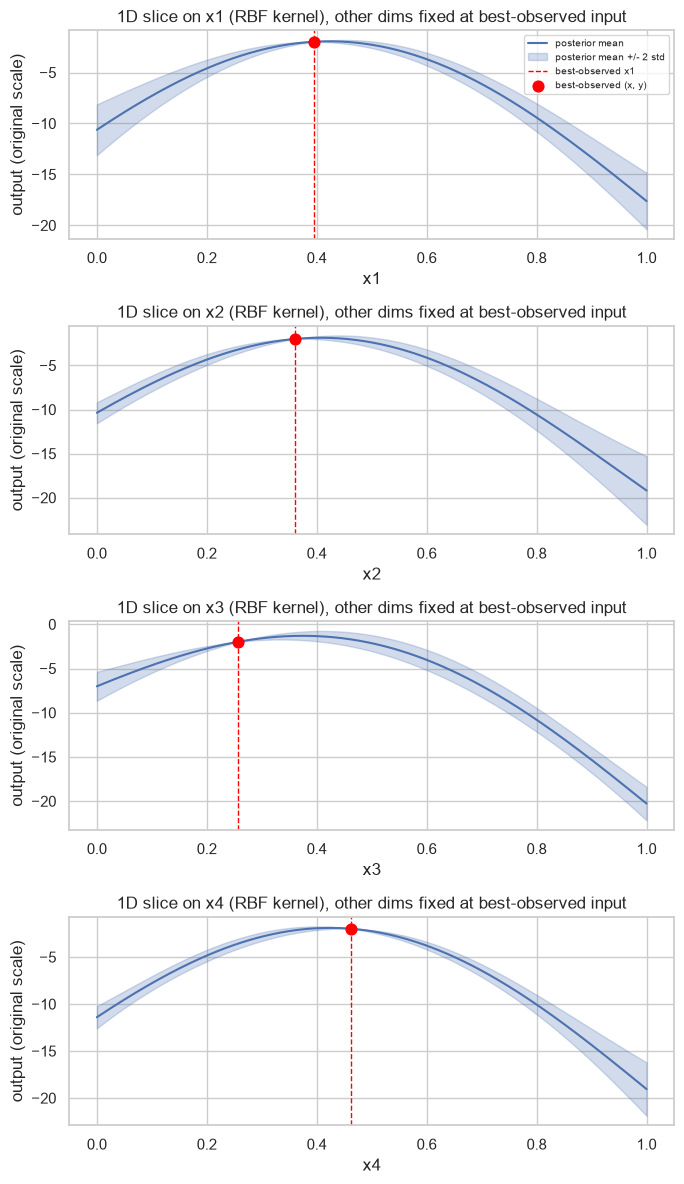

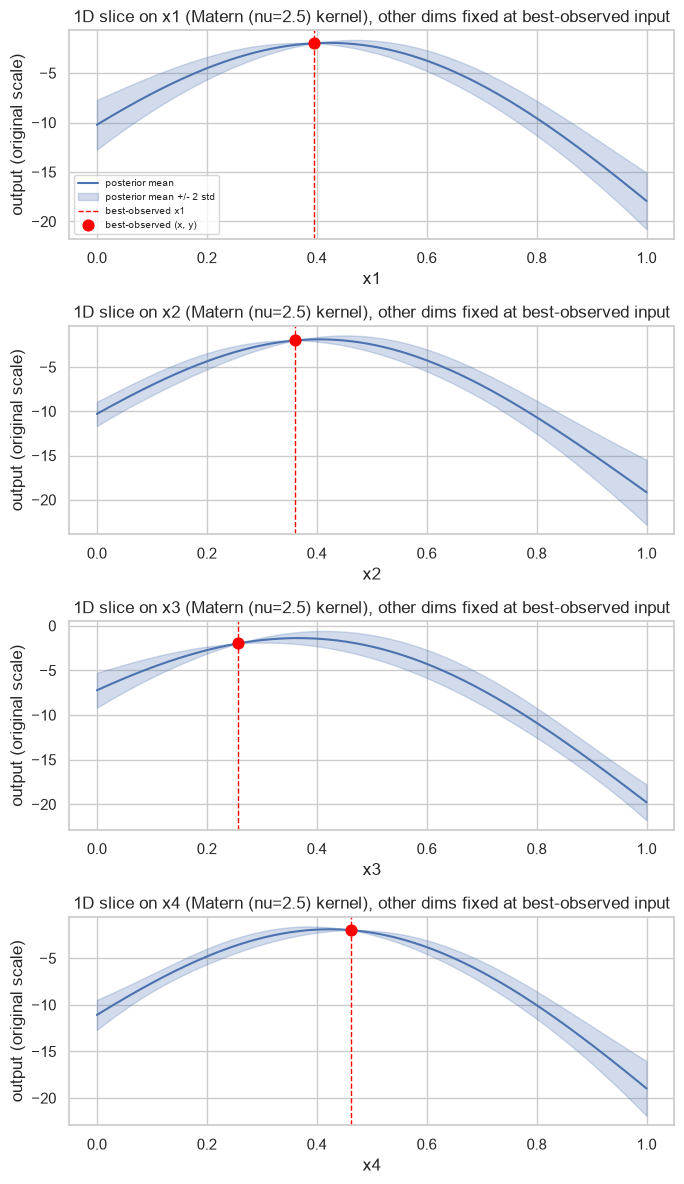

In [16]:
slice_grid = np.linspace(0.0, 0.999999, 200)

for name, gpr in [("rbf", gpr_rbf), ("matern", gpr_matern)]:
    label = name.upper() if name == "rbf" else "Matern (nu=2.5)"
    fig, axes = plt.subplots(d_in, 1, figsize=(7, 3.0 * d_in), squeeze=False)

    for i in range(d_in):
        ax = axes[i][0]
        X_slice = np.tile(best_input, (len(slice_grid), 1))
        X_slice[:, i] = slice_grid

        mean_s, std_s = gpr.predict(X_slice, return_std=True)
        mean = inverse_mean(mean_s)
        std = inverse_std(std_s)

        ax.plot(slice_grid, mean, color="C0", label="posterior mean")
        ax.fill_between(slice_grid, mean - 2 * std, mean + 2 * std, color="C0",
                         alpha=0.25, label="posterior mean +/- 2 std")
        ax.axvline(best_input[i], color="red", linestyle="--", linewidth=1,
                   label="best-observed x{}".format(i + 1))
        ax.scatter([best_input[i]], [best_output], color="red", zorder=5, s=60,
                   label="best-observed (x, y)")
        ax.set_xlabel(f"x{i+1}")
        ax.set_ylabel("output (original scale)")
        ax.set_title(f"1D slice on x{i+1} ({label} kernel), other dims fixed at best-observed input")
        if i == 0:
            ax.legend(fontsize=7, loc="best")

    plt.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f"gp_1d_slices_{name}.png"), dpi=150)
    plt.show()


## 10. Plain-language interpretation

**What the figures suggest.** In the observed-vs-predicted plot (9a), points
falling close to the `y = x` line indicate the selected (or, if neither was
reliably selected, each shown) GP surrogate tracks the training data
reasonably well **in-sample** — which is expected for a GP with a
`WhiteKernel` term fitted on a very small dataset, since the model has
enough flexibility to fit the observed points closely. The residual plots
(9b) are the more informative check: if residuals are small and scattered
without a visible trend against either predicted value or observation
index, that is consistent with no strong systematic misfit at the observed
points; a visible trend (e.g. residuals growing with observation index, or
consistently signed in one region of predicted value) would suggest the
kernel/hyperparameters are not capturing some structure in the data. The
1D slice plots (9d) show where posterior uncertainty (±2 std shaded band)
remains large — typically in regions of input space far from any observed
point — versus where it narrows near observed data, which is the expected
qualitative GP behaviour.

**What cannot yet be concluded.**
- **No held-out validation was performed.** All diagnostics in Section 9
  are in-sample; a GP with a noise term can fit training points closely
  without that implying it predicts well at new, unseen points.
- **Sample sizes remain small** (13–43 observations depending on the
  function), so both the fitted hyperparameters and the LML-based
  comparison between kernels are estimated on very limited evidence.
- **The convergence-aware selection in Section 8c is not the same as a
  statistically validated model comparison.** It only checks whether the
  optimizer search behaved reliably and, secondarily, compares raw
  log-marginal-likelihood — it does not test predictive accuracy on
  unseen data.
- **Regions of the input space with no nearby observations** should be
  treated as genuinely uncertain, even where the posterior mean looks
  smooth — the shaded uncertainty bands in Section 9d are a reminder of
  this, not a guarantee of correctness.

## 11. Chronological validity confirmation

This notebook used **only** the Week 4 cumulative dataset for
Function_04 (`../02_Data/cumulative_inputs.npy` and
`../02_Data/cumulative_outputs.npy`), which itself consists of the Week 3
cumulative dataset plus exactly one independently-verified genuine
historical Week 3 query-output pair appended as its final row. No data from
any later week, and no real Week 4 historical query or output (none exists
yet for this project), was loaded, revealed, referenced, or fabricated
anywhere in this notebook. No `Week_05` location was created or referenced.
All computations, figures, and conclusions above are based solely on data
that was legitimately available at this point in the sequential decision
process.

## 12. Scope boundary — no acquisition-driven query at this stage

**No acquisition function was calculated, and no new query was selected or
saved, anywhere in this notebook.** This notebook is diagnostic/exploratory
only: it performs EDA and fits/compares GP surrogate models on the Week 4
cumulative dataset. No `03_Queries` folder or acquisition-function code was
created anywhere in this project as part of this notebook. The next step —
an acquisition-function-driven query proposal over the GP posterior
established here — remains explicitly **deferred** to a future, separate
step, consistent with this project's stepwise, one-decision-at-a-time
methodology.